# Project: Predicting Clinical Trial Success through Multimodal Data Fusion

This notebook presents the technical proof of concept for our project on predicting clinical trial outcomes. We work with the **louisbrulenaudet/clinical-trials** dataset, where in this P2 deliverable, we want to build simple baseline models for predicting trial success, and show the feasibility of our proposed multimodal approach. 

The notebook is structured as follows:
1. **Exploratory Data Analysis (EDA):** Overview of key dataset features and potential challenges.
2. **Data Splitting and Preprocessing:** Steps for preparing data for modeling and avoiding leakage.
3. **Baseline Model (Structured Data):** A Random Forest classifier trained on trial metadata.
4. **Embeddings Model:** Early experiments using text embeddings to see how informative textual data can be.
5. **Conclusion and Next Steps:** Brief summary of results and plans for the next project stage.


In [1]:
# Libraries

# Core Data Handling and Plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hugging Face Datasets
from datasets import load_dataset, Dataset, ClassLabel

# Scikit-learn for Modeling and Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.utils import resample

# Utility Functions (from our utils.py file)
from utils import fit_and_preprocess_train, transform_test_data

# Set plot style for the notebook
sns.set_style("whitegrid")

# Prevent pandas from using scientific notation for easier reading
pd.options.display.float_format = '{:.2f}'.format

In [2]:
# --- Load the Full Raw Dataset ---
# We load the 'train' split, which contains all the available data,
# and immediately convert it to a pandas DataFrame for EDA.
# If you are running this on your local machine, it sometimes takes a while to load the dataset. 
print("Loading the full dataset from Hugging Face...")
full_df = load_dataset("louisbrulenaudet/clinical-trials", split="train").to_pandas()
print("Dataset loaded.")

# Display initial information about the dataset
print("\nDataset Information:")
full_df.info()

print("\nFirst 5 rows of the raw dataset:")
display(full_df.head())

Loading the full dataset from Hugging Face...
Dataset loaded.

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541897 entries, 0 to 541896
Data columns (total 46 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   nct_id                        541897 non-null  object        
 1   updated_at                    0 non-null       datetime64[us]
 2   brief_title                   541897 non-null  object        
 3   official_title                531911 non-null  object        
 4   acronym                       541897 non-null  object        
 5   study_type                    540977 non-null  object        
 6   overall_status                541897 non-null  object        
 7   study_first_submit_date       541897 non-null  datetime64[ms]
 8   start_date                    0 non-null       datetime64[ms]
 9   primary_completion_date       296575 non-null  datetime64[ms]
 

,nct_id,updated_at,brief_title,official_title,acronym,study_type,overall_status,study_first_submit_date,start_date,primary_completion_date,...,locations,collaborators,arm_groups,outcomes,overall_officials,study_references,misc_info_module,condition_browse_module,intervention_browse_module,mesh_terms
0,NCT01273766,NaT,Deferasirox in Treating Iron Overload Caused B...,Impact of Intervention With Deferasirox on the...,None,INTERVENTIONAL,COMPLETED,2011-01-07,NaT,NaT,...,"[{'city': 'Winston-Salem', 'country': 'United ...","[{'class': 'NIH', 'name': 'National Cancer Ins...",None,"{'other': None, 'primary': [{'description': No...",[{'affiliation': 'Wake Forest University Healt...,None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D004194', 'term': 'Dise...","{'ancestors': [{'id': 'D007502', 'term': 'Iron...","{'conditions': [{'id': 'D002051', 'term': 'Bur..."
1,NCT00787566,NaT,"Phase 2 Study of Efficacy, Tolerability, and S...","A Randomized, Single Administration, Double-bl...",None,INTERVENTIONAL,COMPLETED,2008-11-05,NaT,NaT,...,[{'city': 'The study is managed by Kendle Inte...,None,None,"{'other': None, 'primary': [{'description': No...",None,None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D012817', 'term': 'Sign...","{'ancestors': [{'id': 'D000932', 'term': 'Anti...","{'conditions': [{'id': 'D009325', 'term': 'Nau..."
2,NCT00497666,NaT,Association Between Rosiglitazone Use and Clin...,Retrospective Study Evaluating the Association...,None,OBSERVATIONAL,UNKNOWN,2007-07-06,NaT,NaT,...,"[{'city': 'Zerifin,', 'country': 'Israel', 'fa...",None,None,None,"[{'affiliation': 'Nephrology Division, Assaf H...",None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D014570', 'term': 'Urol...","{'ancestors': None, 'browseBranches': [{'abbre...","{'conditions': [{'id': 'D007674', 'term': 'Kid..."
3,NCT01978366,NaT,Open Label Extension Study of HT-100 in Patien...,An Open Label Extension Study of HT-100 in Pat...,None,INTERVENTIONAL,TERMINATED,2013-10-31,NaT,2016-04-30,...,"[{'city': 'Sacramento', 'country': 'United Sta...",None,None,"{'other': None, 'primary': [{'description': No...","[{'affiliation': 'AkashiTherapeutics', 'name':...",None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D020966', 'term': 'Musc...","{'ancestors': [{'id': 'D000970', 'term': 'Anti...","{'conditions': [{'id': 'D009136', 'term': 'Mus..."
4,NCT01971866,NaT,Camera Based System to Monitor Patient Movemen...,Improving Safety and Accuracy of Proton Therap...,DS02,OBSERVATIONAL,TERMINATED,2013-10-17,NaT,NaT,...,"[{'city': 'Jacksonville', 'country': 'United S...",None,None,"{'other': None, 'primary': [{'description': No...",[{'affiliation': 'University of Florida Proton...,None,"{""versionHolder"": ""2025-06-18""}",None,None,None


--- Original Distribution of Trial Statuses ---
overall_status
COMPLETED                    296549
UNKNOWN                       79051
RECRUITING                    66429
TERMINATED                    31493
NOT_YET_RECRUITING            23878
ACTIVE_NOT_RECRUITING         20916
WITHDRAWN                     15333
ENROLLING_BY_INVITATION        4655
SUSPENDED                      1674
WITHHELD                        920
NO_LONGER_AVAILABLE             490
AVAILABLE                       264
APPROVED_FOR_MARKETING          220
TEMPORARILY_NOT_AVAILABLE        25
Name: count, dtype: int64


C:\Users\esthe\AppData\Local\Temp\ipykernel_33052\282969748.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")


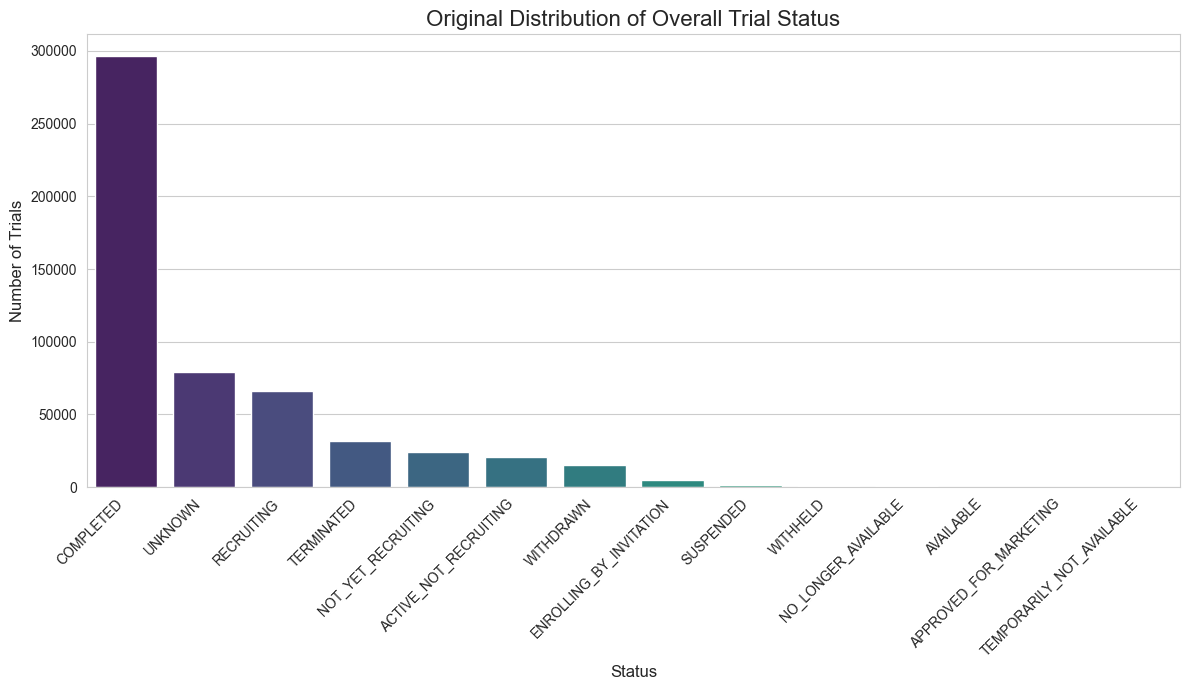

In [3]:
# --- 1.1. Target Variable Analysis: overall_status ---

# First, we look at the original distribution of the 'overall_status' column.
print("--- Original Distribution of Trial Statuses ---")
status_counts = full_df['overall_status'].value_counts()
print(status_counts)

# Next we visualize the distribution
plt.figure(figsize=(12, 7))
sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")
plt.title('Original Distribution of Overall Trial Status', fontsize=16)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Number of Trials', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Defining the Binary Target for EDA

The `overall_status` column contains many different categories, where a lot of them are not definitive outcomes (e.g., "RECRUTING"). For our predictive task, we need a clear binary target representing **Success vs. Failure**. Based on the above plot, we define our classes as follows:

*   **Success (Target = 1):** Trials marked **"COMPLETED"**.
*   **Failure (Target = 0):** Trials that were stopped for definitive negative reasons. We include **"TERMINATED"**, **"WITHDRAWN"**, and **"SUSPENDED"**.

We will filter the dataset to these outcomes to create a clean target for our analysis.

--- Distribution of the Binary Target Variable ---
target
1    296549
0     48500
Name: count, dtype: int64


C:\Users\esthe\AppData\Local\Temp\ipykernel_33052\535026310.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=eda_filtered_df, palette="viridis")


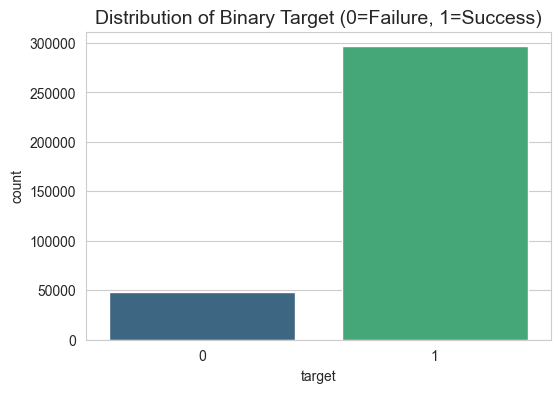

In [4]:
# --- Create a temporary filtered DataFrame for EDA visualization ---
success_stati = ["COMPLETED"]
failure_stati = ["TERMINATED", "WITHDRAWN", "SUSPENDED"]
definitive_stati = success_stati + failure_stati

# Note: This filtered_df is for EDA purposes only. 
# The final filtering for the model will happen within the preprocessing pipeline.
eda_filtered_df = full_df[full_df['overall_status'].isin(definitive_stati)].copy()
eda_filtered_df['target'] = eda_filtered_df['overall_status'].apply(lambda x: 1 if x in success_stati else 0)

# Visualize the new binary target distribution
print("--- Distribution of the Binary Target Variable ---")
print(eda_filtered_df['target'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=eda_filtered_df, palette="viridis")
plt.title('Distribution of Binary Target (0=Failure, 1=Success)', fontsize=14)
plt.show()

# Markdown analysis of the imbalance will go in the final EDA conclusion.

## 1. Exploratory Data Analysis (EDA)

This section focuses on developing a grounded understanding of the clinical trials dataset. Our aim is to understand how the data are structured, examine key patterns and distributions, and identify potential issues such as missing values or class imbalance. These insights form the foundation for the preprocessing and modeling steps that follow. All analyses here use the full, unfiltered dataset.

### 1.2. Structured Feature Analysis

We begin with the structured features that are most likely to influence trial outcomes. These variables were selected for their ability to capture aspects of study design, scale, and participant characteristics:

* **`phases`, `study_type`, `enrollment_count`:** Describe the trial’s stage, format, and size, which together indicate its overall complexity and risk.
* **`lead_sponsor_class`:** Represents the funding source (e.g., industry or academic sponsor), which may correlate with trial design and outcome likelihood.
* **`sex`, `minimum_age`, `maximum_age`:** Define the population under study, helping us gauge demographic scope and potential variability.

Our following analysis examines the extent of missing data and the distributions of these categorical and numerical variables. These findings will guide the development of preprocessing methods and inform early model design decisions.


In [5]:
# --- Missing Values Analysis ---
structured_features = [
    'phases', 'study_type', 'enrollment_count', 
    'lead_sponsor_class', 'sex', 'minimum_age', 'maximum_age'
]

missing_values = eda_filtered_df[structured_features].isnull().sum()
missing_percentage = (missing_values / len(eda_filtered_df)) * 100

print("--- Percentage of Missing Values in Key Features ---")
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

--- Percentage of Missing Values in Key Features ---
maximum_age        46.71
phases             20.69
minimum_age         6.54
enrollment_count    1.24
sex                 0.09
dtype: float64


**Interpretation:**
The missing value analysis reveals several different frequencies of missing values, each with their own set of solutions or challenges:
*   `sex` and `enrollment_count` have very few missing values (<2%), making it safe to simply drop these rows in our processing pipeline.
*   `phases`, `minimum_age`, and `maximum_age` have a moderate to high percentage of missing data (6% to 47%). For these, we will need to use an imputation strategy (e.g., filling with "Unknown" for categoricals or the median for numericals) to avoid losing a significant portion of our dataset. This is the info we needed to design our preprocessing functions. 

--- Distribution of Trial Phases ---


C:\Users\esthe\AppData\Local\Temp\ipykernel_33052\3324141177.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=phase_counts.index, y=phase_counts.values, palette='viridis')


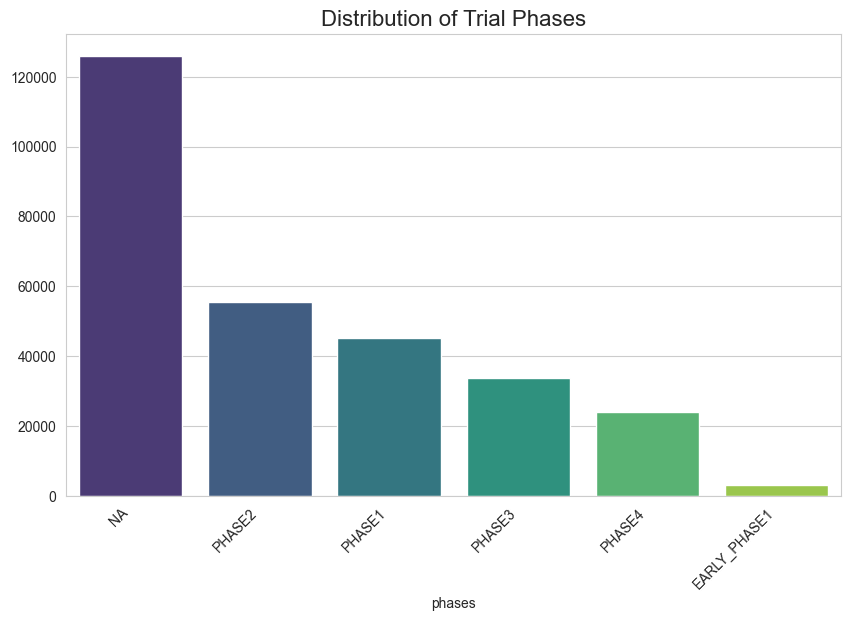

C:\Users\esthe\AppData\Local\Temp\ipykernel_33052\3324141177.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=eda_filtered_df, ax=axes[i], palette='viridis', order=eda_filtered_df[feature].value_counts().index)
C:\Users\esthe\AppData\Local\Temp\ipykernel_33052\3324141177.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=eda_filtered_df, ax=axes[i], palette='viridis', order=eda_filtered_df[feature].value_counts().index)
C:\Users\esthe\AppData\Local\Temp\ipykernel_33052\3324141177.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for

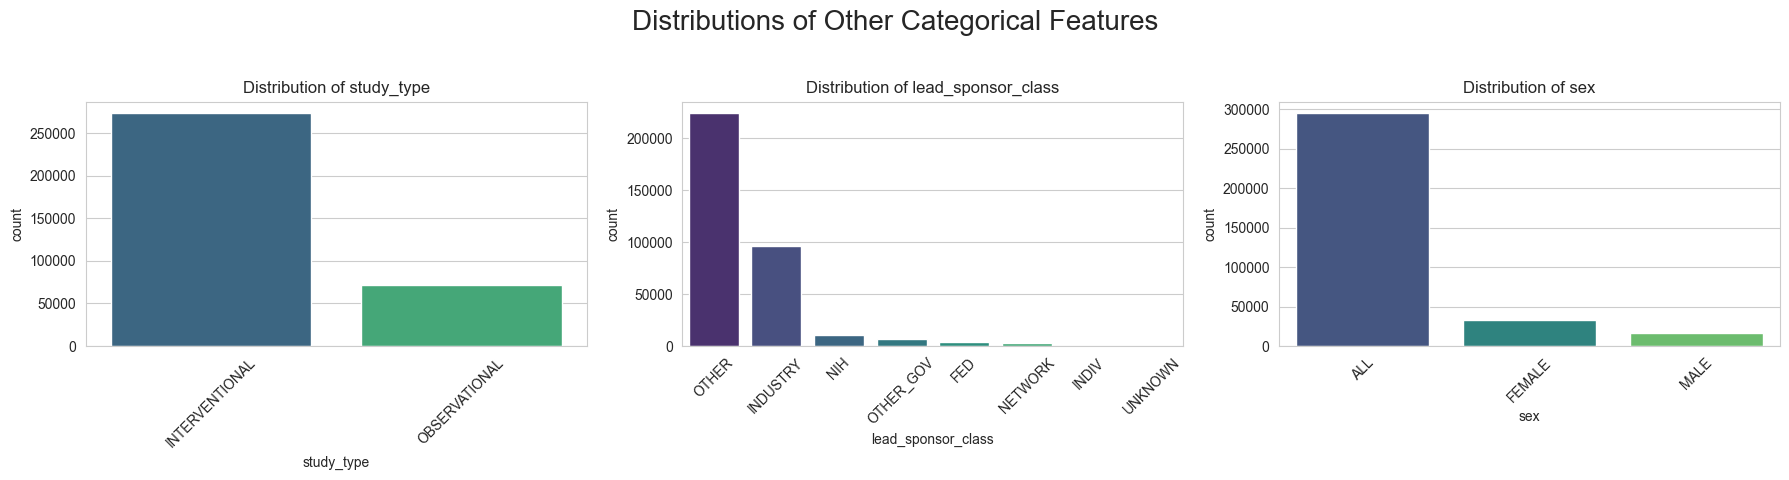

In [6]:
# --- Categorical Feature Distributions ---

# 1. 'phases' column (which contains lists/ndarrays)
print("--- Distribution of Trial Phases ---")
phase_counts = eda_filtered_df['phases'].explode().value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=phase_counts.index, y=phase_counts.values, palette='viridis')
plt.title('Distribution of Trial Phases', fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.show()

# 2. Other categorical features
simple_categorical_features = ['study_type', 'lead_sponsor_class', 'sex']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distributions of Other Categorical Features', fontsize=20)
axes = axes.flatten()
for i, feature in enumerate(simple_categorical_features):
    sns.countplot(x=feature, data=eda_filtered_df, ax=axes[i], palette='viridis', order=eda_filtered_df[feature].value_counts().index)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Interpretation:**

* **Phases:** The distribution is largely dominated by “NA” (Not Applicable) entries. We interpret these as corresponding to observational studies, which typically do not include defined phases. This category is therefore meaningful in itself, rather than simply representing missing data.
* **Sponsor:** The `lead_sponsor_class` feature is very skewed toward “OTHER.” While this limits its immediate interpretability, it still helps distinguish between major sponsor types such as “INDUSTRY” and “NIH.” We also considered a follow-up analysis that groups individual sponsor classes manually, which could improve feature utility in the next project phase (P3).
* **Study Type & Sex:** These features are imbalanced, reflecting the reality of clinical research (more interventional studies, most open to all sexes). This is not a data problem, but rather a real-world pattern our model can learn from.


In [7]:
# --- Numerical Feature Analysis ---
numerical_features = ['enrollment_count', 'minimum_age', 'maximum_age']

# 1. Check data types and summary statistics
print("--- Data Types of Numerical Features ---")
print(eda_filtered_df[numerical_features].dtypes)
print("\n--- Summary Statistics for Numerical Features ---")
display(eda_filtered_df[numerical_features].describe())

--- Data Types of Numerical Features ---
enrollment_count    float64
minimum_age         float64
maximum_age         float64
dtype: object

--- Summary Statistics for Numerical Features ---


,enrollment_count,minimum_age,maximum_age
count,340763.00,322491.00,183888.00
mean,4124.89,20.08,58.63
std,398103.93,11.27,31.16
min,0.00,0.00,1.00
25%,24.00,18.00,45.00
50%,60.00,18.00,65.00
75%,159.00,18.00,75.00
max,188814085.00,730.00,6569.00


**Interpretation of Statistics:**
The summary statistics table is highly revealing:
*   **Skewness:** For all three features, the `mean` is significantly different from the `median` (50%), indicating strong skewness. `enrollment_count` shows the most extreme right skew.
*   **Outliers/Data Quality:** The age columns contain clear data errors or extreme outliers, with a `max` value of 730 for `minimum_age` and 6569 for `maximum_age`. For this baseline proof of concept, we will move on without removing them. Our chosen baseline model for the structured data (See model justification in the model set up section), a Random Forest, is generally robust to such outliers. However, for a more refined model in P3, a potential improvement would be to either cap these values at a reasonable threshold (e.g., 100 years) or remove these outlying rows entirely.

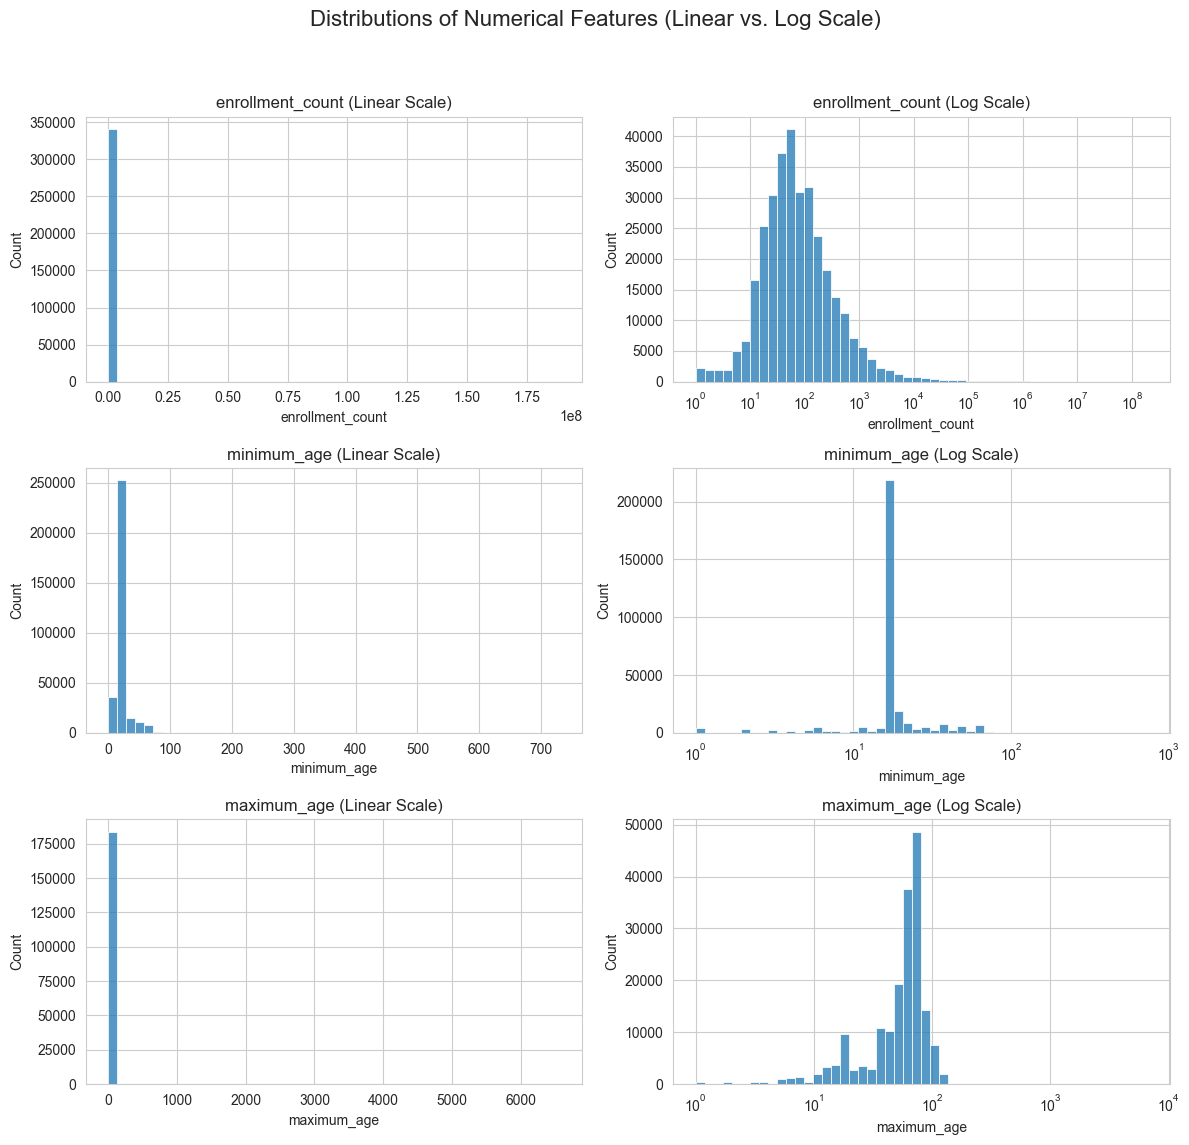

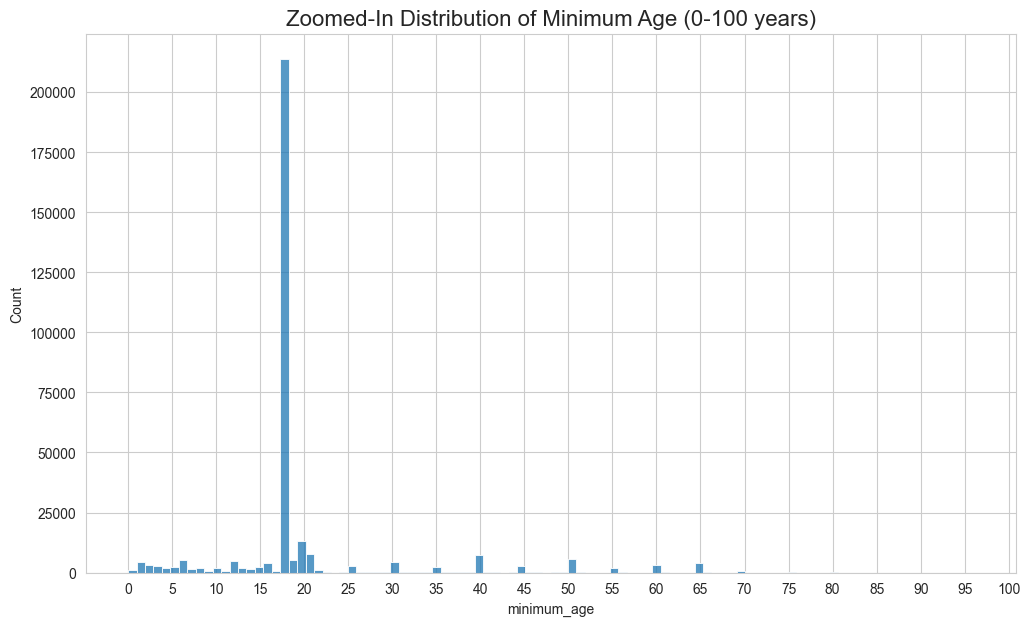

In [8]:
# 2. Plot distributions (Linear vs. Log Scale)
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, 12))
fig.suptitle('Distributions of Numerical Features (Linear vs. Log Scale)', fontsize=16)
for i, feature in enumerate(numerical_features):
    sns.histplot(eda_filtered_df[feature], bins=50, kde=False, ax=axes[i, 0]).set_title(f'{feature} (Linear Scale)')
    sns.histplot(eda_filtered_df[feature], bins=50, kde=False, ax=axes[i, 1], log_scale=True).set_title(f'{feature} (Log Scale)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. "Zoomed-in" plot for minimum_age
zoomed_df = eda_filtered_df[eda_filtered_df['minimum_age'] <= 100]
plt.figure(figsize=(12, 7))
sns.histplot(data=zoomed_df, x='minimum_age', bins=100)
plt.title('Zoomed-In Distribution of Minimum Age (0-100 years)', fontsize=16)
plt.xticks(ticks=range(0, 101, 5))
plt.show()

**Interpretation of Plots:**
*   The log-scaled plots confirm the right-skew of `enrollment_count` and `maximum_age`.
*   The zoomed-in plot for `minimum_age` tells us the most. It proves that this feature does not have a smooth distribution and instead acts like a combination of a smooth distribution at low ages and a **categorical variable**, dominated by specific values like 0, 18, and other "round number" age cutoffs (40, 50, 65). This is likely because many studies aimed at lower age groups have specific age requirements where a few years' difference is developmentally significant (e.g., 13 vs. 16 years old), while studies targeting older adults often use broader, round-number cutoffs where the difference between 40 and 42 is less critical. This is an important finding that suggests a simple numerical treatment may be insufficient for a final model. For P2 we did not change this category, but we noted that this is a potential avenue for improvement. 

### 1.3. Investigating the Text Embeddings

The final step of our EDA was to locate the pre-trained text embeddings mentioned in the dataset's description (`brief_summary_embedding` and `eligibility_criteria_embedding`). These high-dimensional features are the main columns we need for our project's multimodal hypothesis, as they are expected to capture the rich semantic content of the trial's purpose and its inclusion/exclusion rules.

However, when exploring the dataset, we found that it did not include the promised enriched text columns. 

In [9]:
# --- Diagnostic Check for Embedding Columns ---

# We inspect the columns of our loaded full_df to search for any column containing 'embedding'.
embedding_related_columns = [col for col in full_df.columns if 'embedding' in col.lower()]

if not embedding_related_columns:
    print("Diagnostic Result: No columns containing 'embedding' were found in the initial dataframe.")
    print("\nConclusion: The embeddings must be generated manually.")
else:
    print("Embedding columns found:", embedding_related_columns)

print("\nFull list of available columns:")
print(full_df.columns.tolist())

Diagnostic Result: No columns containing 'embedding' were found in the initial dataframe.

Conclusion: The embeddings must be generated manually.

Full list of available columns:
['nct_id', 'updated_at', 'brief_title', 'official_title', 'acronym', 'study_type', 'overall_status', 'study_first_submit_date', 'start_date', 'primary_completion_date', 'completion_date', 'phases', 'enrollment_count', 'minimum_age', 'maximum_age', 'sex', 'healthy_volunteers', 'brief_summary', 'detailed_description', 'eligibility_criteria', 'lead_sponsor_name', 'lead_sponsor_class', 'org_study_id_info', 'why_stopped', 'expanded_access_info', 'last_update_submit_qc_date', 'last_update_post_date_struct', 'study_first_post_date_struct', 'std_ages', 'study_population', 'sampling_method', 'oversight_has_dmc', 'design_info', 'conditions', 'keywords', 'interventions', 'locations', 'collaborators', 'arm_groups', 'outcomes', 'overall_officials', 'study_references', 'misc_info_module', 'condition_browse_module', 'interve

### Our Solution: Manual Embedding Generation

Given that the embeddings were not included in the dataset, we adapted our plan to generate them ourselves, following the code provided in the dataset's documentation. This represents a significant NLP task that adds depth to our project's proof of concept.

**Workflow:**
1.  **Model Selection:** We used the recommended `thomas-sounack/BioClinical-ModernBERT-base` model from the `sentence-transformers` library, a powerful transformer model pre-trained on biomedical text.
2.  **Computational Constraints:** Generating embeddings for the entire dataset (~540,000 trials) is a computationally intensive process. Our initial attempt to run this on the full dataset in Google Colab timed out after 4.5 hours, having processed only about 30% of the data.
3.  **Subsetting for P2:** To create a doable and reproducible proof of concept that could be completed within a reasonable timeframe, we created a representative **subset of ~140,000 trials (approx. 25% of the full dataset)**. This size was chosen as a practical balance to make sure that the generation process would complete successfully before Google Colabs runtime timed out. 
4.  **Generation on Colab:** We performed the embedding generation for both the `brief_summary` and `eligibility_criteria` columns on this subset using a dedicated Google Colab notebook (`subset-embedding-training.ipynb`) with GPU acceleration. This notebook can be found under the appendix in the `README.md`. 
5.  **Saving the Result:** The final, enhanced DataFrame, containing all original metadata plus the two new 768-dimensional embedding columns—was saved to a compressed **Parquet file** (`subset_dataset_with_embeddings.parquet`). The dataset is not included in the repo due to size, but you can find the link  under the appendix in the `README.md`. 

**Path Forward:**
All subsequent analysis, preprocessing, and modeling in this notebook will be performed on a consistent train/test split derived from this new, enhanced subset dataset. This ensures a fair and direct comparison between our structured data baseline and our embeddings-based models. The code for loading this subset is the first step in our Data Preparation section.

## EDA Conclusion

Our exploratory analysis has provided several good insights that directly inform our project's next steps:
1.  **A Clear (but Imbalanced) Target:** We have successfully defined a binary target variable ("Success" vs. "Failure"), but its severe class imbalance is the primary challenge we must address.
2.  **Informative (but Messy) Features:** The structured features show clear patterns and distributions that we **hypothesize contain predictive signals** (e.g., the difference in `phases` or `study_type`). However, they also suffer from missing data, skewness, and data quality issues (e.g., age outliers). Our preprocessing pipeline must be designed to handle these issues robustly to effectively test this hypothesis.
3.  **A Necessary Workflow Pivot:** The absence of pre-computed embeddings required us to adapt our plan to include a manual generation step, leading to the creation of a smaller, enhanced subset for our proof-of-concept models. We hope to find a way we can train the embeddings for the full dataset during P3. 

With this new and deeper understanding of the data, we are now ready to move on to the formal data preparation and modeling phase.

## 2. Data Preparation and Pipeline

Based on our EDA findings, we now move to the formal data preparation stage. The goal is to create a clean, consistent, and leak-free set of training and testing data for both our structured and embeddings-based models.

### 2.1. The Preprocessing Utility Functions (`utils.py`)

To ensure our preprocessing is modular, reusable, and consistently applied, we have encapsulated the logic into two functions stored in a separate `utils.py` file. This `fit`/`transform` paradigm is a standard best practice that prevents data leakage from the test set into the training process.

1.  **`fit_and_preprocess_train(train_df)`:** This function learns transformation parameters (like medians and scaling factors) exclusively from the training data and applies them. It returns a processed training DataFrame and a `transformation_rules` dictionary.

2.  **`transform_test_data(test_df, rules)`:** This function takes the test data and the `transformation_rules` dictionary and applies the already learned transformations, ensuring the test set is treated as unseen data.

### 2.2. Detailed Preprocessing Steps

The pipeline implemented in our utility functions performs the following sequential operations on the structured data:

*   **1. Feature Selection:** It first selects the seven structured features identified during our EDA: `phases`, `study_type`, `enrollment_count`, `lead_sponsor_class`, `sex`, `minimum_age`, and `maximum_age`.

*   **2. Outcome Filtering:** It filters the dataset to only include trials with a definitive outcome, defined as "COMPLETE", "TERMINATED", "WITHDRAWN", or "SUSPENDED".

*   **3. Handling Missing Values:** Based on our EDA, it applies the following strategies:
    *   **Row Dropping:** It drops rows where `sex` or `enrollment_count` are missing, as these constitute less than 2% of the data.
    *   **Categorical Imputation:** It fills missing `NaN` values in the `phases` column with the string `"Unknown"`, treating this missingness as a distinct category.
    *   **Numerical Imputation:** It fills missing `NaN` values in `minimum_age` and `maximum_age` with the median value calculated only from the training set.

*   **4. One-Hot Encoding:** It converts the four categorical features (`phases`, `study_type`, `lead_sponsor_class`, `sex`) into a numerical format using one-hot encoding. The encoder is configured with `handle_unknown='ignore'`, which makes sure that if a new, unseen category appears in the test data, it is handled correctly by being encoded as a row of all zeros, preventing errors.

*   **5. Numerical Scaling:** It standardizes the three numerical features (`enrollment_count`, `minimum_age`, `maximum_age`) using a `StandardScaler`, which scales the data to have a mean of 0 and a standard deviation of 1.

This detailed pipeline ensures our data is clean, purely numerical, and ready for modeling.

###  2.2. Load Enhanced Subset and Create Train/Test Split

In [10]:
# First, we load the subset DataFrame containing the pre-generated embeddings.
# This dataset should be in your working directory! If it isnt, you can find a link to download it in the appendix in the `README.md`.
print("Loading the subset dataset with embeddings from Parquet file...")
subset_df_with_embeddings = pd.read_parquet('subset_dataset_with_embeddings.parquet')
print("Dataset loaded.")

# Now, we create the train/test split for the rest of the notebook.
# We want to make sure the same train/test split is used in all baseline models and experiments to ensure we stay consistent and have comparable outcomes. 

# We stratify on 'overall_status' to maintain the class distribution in both sets.
print("\nSplitting the subset into training and testing sets (80/20 split)...")
raw_train_df, raw_test_df = train_test_split(
    subset_df_with_embeddings,
    test_size=0.2,
    random_state=42,
    stratify=subset_df_with_embeddings['overall_status']
)
print("Splitting complete.")
print(f"Raw training set size: {len(raw_train_df)}")
print(f"Raw testing set size: {len(raw_test_df)}")

Loading the subset dataset with embeddings from Parquet file...
Dataset loaded.

Splitting the subset into training and testing sets (80/20 split)...
Splitting complete.
Raw training set size: 112000
Raw testing set size: 28000


### 2.3. Execute the Structured Data Preprocessing Pipeline

In [11]:
# We now feed our raw splits into the utility functions.
print("\nPreprocessing structured data for the baseline model...")

# The fit_and_preprocess_train function learns rules ONLY from the training set.
processed_train_df, new_transformation_rules = fit_and_preprocess_train(raw_train_df)

# The transform_test_data function applies those learned rules to the test set.
processed_test_df = transform_test_data(raw_test_df, new_transformation_rules)

print("\nStructured data preprocessing complete.")

# Display the head of the final processed training data to confirm the structure.
print("\nHead of the final processed training data (for structured model):")
display(processed_train_df.head())


Preprocessing structured data for the baseline model...
Dropped 950 rows with missing 'sex' or 'enrollment_count'.
Training data preprocessed successfully according to the specific plan.
Test data transformed successfully using training set rules.

Structured data preprocessing complete.

Head of the final processed training data (for structured model):


,enrollment_count,minimum_age,maximum_age,phases_EARLY_PHASE1,phases_NA,phases_PHASE1,phases_PHASE2,phases_PHASE3,phases_PHASE4,phases_Unknown,...,lead_sponsor_class_INDUSTRY,lead_sponsor_class_NETWORK,lead_sponsor_class_NIH,lead_sponsor_class_OTHER,lead_sponsor_class_OTHER_GOV,lead_sponsor_class_UNKNOWN,sex_ALL,sex_FEMALE,sex_MALE,target
76856,-0.01,-0.18,-2.01,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1
3206,-0.01,-0.18,0.15,0.00,0.00,0.00,0.00,0.00,0.00,1.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1
73216,-0.01,2.77,0.15,0.00,0.00,0.00,0.00,1.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0
1259,-0.02,-0.08,0.15,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0
120625,-0.01,-0.73,0.47,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1


## 3. Baseline Model: Structured Metadata

With our data split and the structured features preprocessed, we can now build our first proof-of-concept model. The goal is to establish a performance benchmark using only the structured metadata.

For this baseline, we will start directly with a **Random Forest Classifier**. While a simpler linear model like Logistic Regression is often a first step, our EDA revealed that the relationships between features (e.g., the semi-categorical nature of `minimum_age`) are likely non-linear. A Random Forest is a powerful ensemble model that works well at capturing these complex, non-linear interactions in tabular data right out of the box, making it a strong and realistic choice for a robust baseline. It also provides feature importances, which will give us initial insights into which structured features are most predictive.


In [12]:
# --- 3.1. Prepare Data for Model Training ---

# Separate the features (X) and the target (y) for both training and testing sets.
X_train = processed_train_df.drop('target', axis=1)
y_train = processed_train_df['target']

X_test = processed_test_df.drop('target', axis=1)
y_test = processed_test_df['target']

# --- Sanity Check the final shapes ---
print("--- Final Shapes for Structured Model ---")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

--- Final Shapes for Structured Model ---
Shape of X_train: (70399, 23)
Shape of y_train: (70399,)
Shape of X_test: (17588, 23)
Shape of y_test: (17588,)


In [13]:
# --- 3.2. Train the Random Forest Classifier ---

# Initialize the classifier with parameters for reproducibility and speed.
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the training data.
print("Training the Random Forest baseline model...")
rf_classifier.fit(X_train, y_train)
print("Training complete.")

# --- Make Predictions on the Test Data ---
print("\nMaking predictions on the test set...")
y_pred = rf_classifier.predict(X_test)
print("Predictions complete.")

Training the Random Forest baseline model...
Training complete.

Making predictions on the test set...
Predictions complete.


### Evaluate the Model

--- Baseline Model Classification Report ---
              precision    recall  f1-score   support

 Failure (0)       0.69      0.48      0.57      2498
 Success (1)       0.92      0.97      0.94     15090

    accuracy                           0.90     17588
   macro avg       0.81      0.72      0.75     17588
weighted avg       0.89      0.90      0.89     17588


--- Confusion Matrix for Baseline Model ---


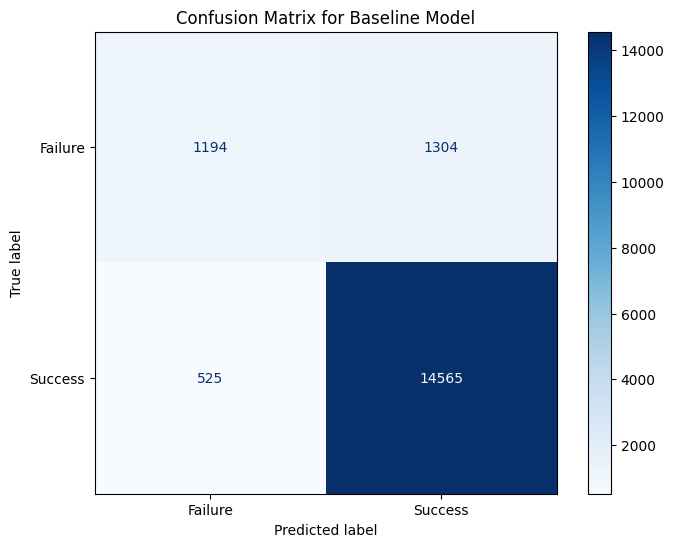

In [14]:
# --- 3.3. Evaluate the Baseline Model ---

print("--- Baseline Model Classification Report ---")
report = classification_report(y_test, y_pred, target_names=['Failure (0)', 'Success (1)'])
print(report)

print("\n--- Confusion Matrix for Baseline Model ---")
# Use the style context to ensure the plot is clean
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        ax=ax,
        display_labels=['Failure', 'Success'],
        cmap='Blues'
    )
    plt.title("Confusion Matrix for Baseline Model")
    plt.show()

### Analysis of the Baseline Model Performance

The Random Forest baseline model, trained on the structured data from our subset, achieves a high overall accuracy of 90%. However, this metric is misleading due to the severe class imbalance in our target variable.

**Performance on the "Success" (Majority) Class:**
The model is highly effective at identifying successful trials, achieving an F1-score of 0.94. The confusion matrix shows it correctly identifies 14,565 true successes while only missing 525.

**Performance on the "Failure" (Minority) Class:**
The model's key weakness is its performance on the "Failure" class, which directly confirms our EDA hypothesis about the imbalance.
*   **Recall (0.48):** The model only identifies 48% of all actual failures, misclassifying over half of them (1,304) as successes.
*   **F1-Score (0.57):** This low F1-score is a direct consequence of the poor recall and serves as our primary benchmark for this class.

**Conclusion:**
This proof of concept successfully establishes a baseline. The model is heavily biased towards the majority class, demonstrating that simply training on the raw, imbalanced data is insufficient for reliably detecting trial failures. This result strongly motivates the need for the class balancing strategies we will explore in P3.

## 4. Embeddings Model: Initial Version

Now we will build our second proof of concept using only the text embeddings. The goal is to isolate the predictive power of the semantic information from the trial summaries.

Unlike the structured data, high-dimensional embeddings (1536 dimensions in our case, which come from the concatenating the two separate 768-dimensional embedding vectors) often contain strong linear patterns that can be captured by simpler models. Therefore, following a standard methodology for text classification, we will start with the simplest possible baseline to see if a linear signal exists.

### 4a. Linear Model (Logistic Regression)

We will begin with a `LogisticRegression` model. This is a fast, highly efficient model that serves as an excellent first-pass test to determine if there is a linearly separable relationship between the text embeddings and the trial outcomes.


In [15]:
# --- 4.1. Prepare Data for Embeddings Model ---

# Define our definitive outcomes (ensure consistency)
success_stati = ["COMPLETED"]
failure_stati = ["TERMINATED", "WITHDRAWN", "SUSPENDED"]
definitive_stati = success_stati + failure_stati

# Filter the raw dataframes to only include definitive outcomes
# This ensures we use the exact same set of trials as the structured baseline
train_emb_df = raw_train_df[raw_train_df['overall_status'].isin(definitive_stati)].copy()
test_emb_df = raw_test_df[raw_test_df['overall_status'].isin(definitive_stati)].copy()

# Create the binary 'target' column on these filtered dataframes
train_emb_df['target'] = train_emb_df['overall_status'].apply(lambda x: 1 if x in success_stati else 0)
test_emb_df['target'] = test_emb_df['overall_status'].apply(lambda x: 1 if x in success_stati else 0)

# --- Extract and Combine Embeddings ---

# Extract from the FILTERED training data
X_train_emb_summary = np.vstack(train_emb_df['brief_summary_embedding'].values)
X_train_emb_criteria = np.vstack(train_emb_df['eligibility_criteria_embedding'].values)

# Extract from the FILTERED test data
X_test_emb_summary = np.vstack(test_emb_df['brief_summary_embedding'].values)
X_test_emb_criteria = np.vstack(test_emb_df['eligibility_criteria_embedding'].values)

# --- Sanity Check: Verify the dimensions ---
print("--- Sanity Checking Embedding Shapes ---")
print(f"Shape of train summary embeddings: {X_train_emb_summary.shape}")
print(f"Shape of train criteria embeddings: {X_train_emb_criteria.shape}")
print(f"The dimension of a single embedding vector is {X_train_emb_summary.shape[1]}.")

# Concatenate them to create the final feature matrices
X_train_emb_np = np.concatenate([X_train_emb_summary, X_train_emb_criteria], axis=1)
X_test_emb_np = np.concatenate([X_test_emb_summary, X_test_emb_criteria], axis=1)

# Extract the corresponding target vectors
y_train_emb = train_emb_df['target'].values
y_test_emb = test_emb_df['target'].values

print(f"\nShape of the final, concatenated TRAIN feature matrix: {X_train_emb_np.shape}")
print(f"Shape of the final, concatenated TEST feature matrix: {X_test_emb_np.shape}")

--- Sanity Checking Embedding Shapes ---
Shape of train summary embeddings: (71349, 768)
Shape of train criteria embeddings: (71349, 768)
The dimension of a single embedding vector is 768.

Shape of the final, concatenated TRAIN feature matrix: (71349, 1536)
Shape of the final, concatenated TEST feature matrix: (17836, 1536)


In [16]:
# --- 4.2. Train the Logistic Regression Model ---

# Initialize the classifier
# max_iter is a hyperparameter. We need it because Logistic regression 
# uses iterative optimization to minimize the loss function. 
# The optimization either stops when convergance is reached or the number 
# of iteration reaches the chosen hyperparameter. 
lr_classifier = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)

# Train the model on the embeddings data
print("Training the Logistic Regression model on embeddings...")
lr_classifier.fit(X_train_emb_np, y_train_emb)
print("Training complete.")

# --- Make Predictions on the Test Set ---
print("\nMaking predictions on the test set...")
y_pred_emb_lr = lr_classifier.predict(X_test_emb_np)
print("Predictions complete.")

Training the Logistic Regression model on embeddings...
Training complete.

Making predictions on the test set...
Predictions complete.



--- Embeddings Model (Logistic Regression) Classification Report ---
              precision    recall  f1-score   support

 Failure (0)       0.41      0.03      0.06      2505
 Success (1)       0.86      0.99      0.92     15331

    accuracy                           0.86     17836
   macro avg       0.64      0.51      0.49     17836
weighted avg       0.80      0.86      0.80     17836


--- Confusion Matrix for Embeddings Model (Logistic Regression) ---


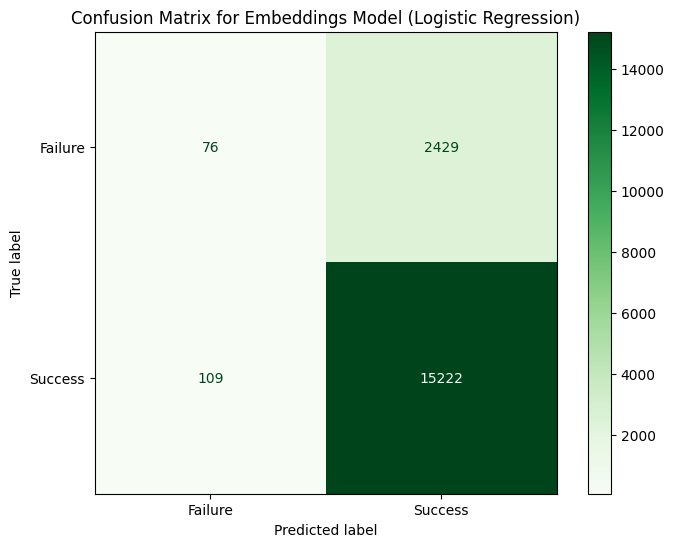

In [17]:
# --- 4.3. Evaluate the Logistic Regression Model ---

print("\n--- Embeddings Model (Logistic Regression) Classification Report ---")
report_emb_lr = classification_report(y_test_emb, y_pred_emb_lr, target_names=['Failure (0)', 'Success (1)'])
print(report_emb_lr)

print("\n--- Confusion Matrix for Embeddings Model (Logistic Regression) ---")
# Use the style context to ensure the plot is clean
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test_emb, 
        y_pred_emb_lr, 
        ax=ax,
        display_labels=['Failure', 'Success'],
        cmap='Greens' 
    )
    plt.title("Confusion Matrix for Embeddings Model (Logistic Regression)")
    plt.show()

### Analysis of the Logistic Regression Performance

This initial embeddings model acts as a successful proof of concept, however, its predictive performance is very poor. The overall accuracy of 86% is misleading, and the macro avg f1-score of 0.49 reveals its ineffectiveness.

**Performance on the "Failure" (Minority) Class:**
The model's performance on this class is really poor.
*   **Recall (0.03):** The model only identifies 3% of all actual failures, missing **2,429** of them as shown in the confusion matrix.
*   **F1-Score (0.06):** This extremely low score confirms that this simple linear model has almost completely failed to learn meaningful patterns from the embeddings to identify failed trials.

**Conclusion:**
A simple `LogisticRegression` model is not powerful enough to find the complex signals in the high-dimensional embedding space, especially given the class imbalance. It has defaulted to an extremely biased decision boundary, almost always predicting success. This result motivates our next step: testing a more powerful, non-linear model.

### 4b. Non-Linear Model (Random Forest)

The `LogisticRegression` model's failure suggests that either the signal in the embeddings is too weak for any model, or that the relationship between the embeddings and trial outcomes is non-linear and requires a more complex model to capture.

To test this second hypothesis, we will now use a **`RandomForestClassifier`**. As a powerful, non-linear ensemble model, it can capture complex interactions within the 1536-dimensional feature space that a linear model cannot. This will help us determine if the poor performance was due to the model's simplicity or a fundamental lack of signal in the data. This also allows for a more direct comparison between the structured data model and this one, due to the model families being the same. 

In [18]:
# --- 4.4. Train the Random Forest Classifier on Embeddings ---

# Initialize the classifier
# The n_estimators and max_depth are hyperparameters. The former
# defines how many trees we have in our random forest. The 
# latter is the number of split each tree can grow to. This controls the complexity.
rf_emb_classifier = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1,
    max_depth=10 # Limiting depth helps control training time and prevent overfitting
)

# Train the model on the same embeddings data
print("Training the Random Forest model on embeddings...")
# We use the same X_train_emb_np and y_train_emb from the previous step
rf_emb_classifier.fit(X_train_emb_np, y_train_emb)
print("Training complete.")

# --- Make Predictions ---
print("\nMaking predictions with the Random Forest model...")
y_pred_emb_rf = rf_emb_classifier.predict(X_test_emb_np)
print("Predictions complete.")

Training the Random Forest model on embeddings...
Training complete.

Making predictions with the Random Forest model...
Predictions complete.



--- Embeddings Model (Random Forest) Classification Report ---
              precision    recall  f1-score   support

 Failure (0)       0.00      0.00      0.00      2505
 Success (1)       0.86      1.00      0.92     15331

    accuracy                           0.86     17836
   macro avg       0.43      0.50      0.46     17836
weighted avg       0.74      0.86      0.79     17836


--- Confusion Matrix for Embeddings Model (Random Forest) ---


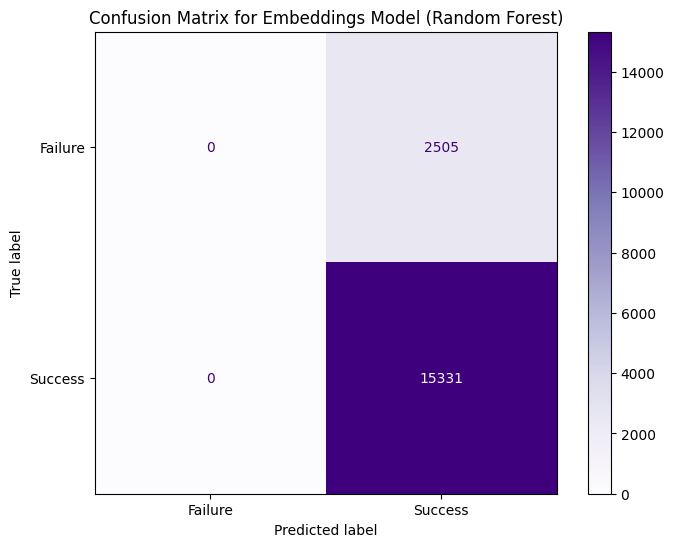

In [19]:
# --- 4.5. Evaluate the Random Forest (Embeddings) ---

print("\n--- Embeddings Model (Random Forest) Classification Report ---")
report_emb_rf = classification_report(y_test_emb, y_pred_emb_rf, target_names=['Failure (0)', 'Success (1)'], zero_division=0)
print(report_emb_rf)

print("\n--- Confusion Matrix for Embeddings Model (Random Forest) ---")
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test_emb, 
        y_pred_emb_rf, 
        ax=ax,
        display_labels=['Failure', 'Success'],
        cmap='Purples'
    )
    plt.title("Confusion Matrix for Embeddings Model (Random Forest)")
    plt.show()

### Analysis of the Random Forest (Embeddings) Performance

The result of the Random Forest model is even worse than the Logistic Regression. Despite being a more powerful, non-linear model, its performance on the minority class collapsed completely.

**Performance on the "Failure" (Minority) Class:**
The model entirely failed to identify any "Failure" cases.
*   The `precision`, `recall`, and `f1-score`** are all 0.00.
*   The confusion matrix confirms this starkly, showing 0 True Negatives. The model never once predicted "Failure," and misclassified all 2,505 actual failures as "Success."

**Conclusion: A "Lazy Classifier" Confirmed**
This experiment proves that simply increasing model complexity is not the solution. The Random Forest, faced with the severe class imbalance and noisy high-dimensional data, found that the optimal strategy to minimize its overall error was to ignore the minority class completely and always predict the majority class.

This provides the strongest possible evidence that the primary issue is not the model architecture, but the data itself. This definitively justifies our hypothesis that a data-level intervention, such as class balancing, is the necessary next step.

### 4c. Downsampling Experiment (A Quick Test for P2)

Our analysis has now clearly shown that both linear and non-linear models fail on the imbalanced text embedding data. Like we discussed above, we hypothesize that his is due to the data distribution and not the model choice. 

To test this hypothesis and provide a proof of concept for our P3 plan, we will do a final experiment using a simple random downsampling strategy. This idea comes from Li, 2025 (full source is in the appendix of the README file). The goal is to see if a model trained on a balanced dataset can learn to identify the "Failure" class more effectively, even if it means sacrificing some performance on the "Success" class.

In [20]:
# --- 4.6. Downsampling the Training Data ---

from sklearn.utils import resample

# We first need to combine our training features and labels into a single DataFrame to manage the sampling.
# We'll use the already filtered `train_emb_df` for this.
X_train_emb_df_for_resample = train_emb_df[['brief_summary_embedding', 'eligibility_criteria_embedding', 'target']]

# 1. Separate the majority and minority classes
df_majority = X_train_emb_df_for_resample[X_train_emb_df_for_resample.target == 1]
df_minority = X_train_emb_df_for_resample[X_train_emb_df_for_resample.target == 0]

# 2. Downsample the majority class
df_majority_downsampled = resample(df_majority, 
                                 replace=False,    # sample without replacement
                                 n_samples=len(df_minority), # to match minority class size
                                 random_state=42) # for reproducibility

# 3. Combine the downsampled majority with the original minority
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

print(f"Original training set size (definitive outcomes): {len(train_emb_df)}")
print(f"Downsampled training set size: {len(df_downsampled)}")
print(f"New class distribution in training set:\n{df_downsampled.target.value_counts()}")

# --- Prepare the final downsampled training data ---
# Extract summary and criteria embeddings separately, then vstack and concatenate
X_train_ds_summary = np.vstack(df_downsampled['brief_summary_embedding'].values)
X_train_ds_criteria = np.vstack(df_downsampled['eligibility_criteria_embedding'].values)
X_train_downsampled_np = np.concatenate([X_train_ds_summary, X_train_ds_criteria], axis=1)
y_train_downsampled = df_downsampled.target.values

# --- 4.7. Train a NEW Random Forest on the BALANCED data ---
rf_downsampled_classifier = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1,
    max_depth=10 
)

print("\nTraining Random Forest on downsampled data...")
rf_downsampled_classifier.fit(X_train_downsampled_np, y_train_downsampled)
print("Training complete.")

# --- 5. Evaluate on the ORIGINAL, UNBALANCED test set ---
# We use the original X_test_emb_np and y_test_emb to get an honest performance measure.
print("\nMaking predictions on the original unbalanced test set...")
y_pred_downsampled = rf_downsampled_classifier.predict(X_test_emb_np)
print("Predictions complete.")

Original training set size (definitive outcomes): 71349
Downsampled training set size: 20048
New class distribution in training set:
target
1    10024
0    10024
Name: count, dtype: int64

Training Random Forest on downsampled data...
Training complete.

Making predictions on the original unbalanced test set...
Predictions complete.



--- Embeddings Model (Downsampled Random Forest) Classification Report ---
              precision    recall  f1-score   support

 Failure (0)       0.23      0.63      0.34      2505
 Success (1)       0.92      0.66      0.77     15331

    accuracy                           0.66     17836
   macro avg       0.57      0.64      0.55     17836
weighted avg       0.82      0.66      0.71     17836


--- Confusion Matrix for Downsampled Model ---


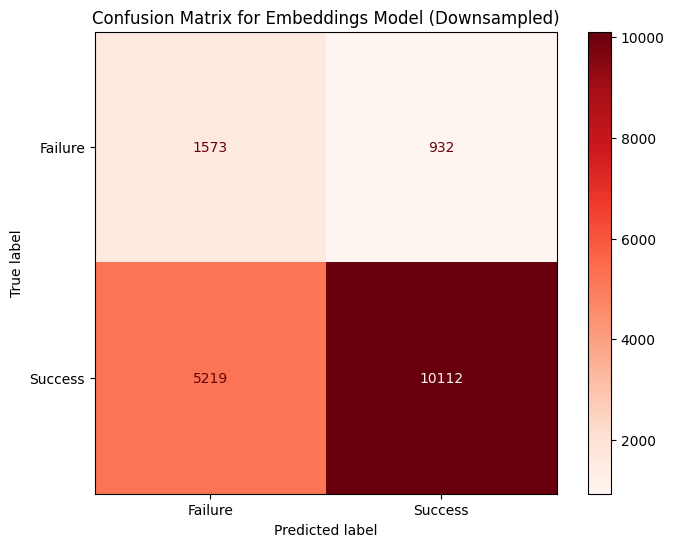

In [21]:
# --- 4.8. Evaluate the Downsampled Model ---

print("\n--- Embeddings Model (Downsampled Random Forest) Classification Report ---")
report_downsampled = classification_report(y_test_emb, y_pred_downsampled, target_names=['Failure (0)', 'Success (1)'])
print(report_downsampled)

print("\n--- Confusion Matrix for Downsampled Model ---")
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test_emb, 
        y_pred_downsampled, 
        ax=ax,
        display_labels=['Failure', 'Success'],
        cmap='Reds',
        values_format='d'
    )
    plt.title("Confusion Matrix for Embeddings Model (Downsampled)")
    plt.show()

### Analysis of the Downsampled Model Performance

This experiment  provides clear validation for our P3 strategy. By training the Random Forest on a balanced dataset, the model's ability to predict the failure class improved significantly, and it did not lose too much predictive power from the success class. 

**Impact on the "Failure" (Minority) Class:**
This is where the most significant improvement occurred.
*   **Recall (0.63):** This is a massive improvement over the previous model's 0.00. By learning from a balanced set, the model now correctly identifies 63% of all actual failures. The confusion matrix shows it found 1,573 true negatives, proving that a strong predictive signal does exist in the embeddings.
*   **F1-Score (0.34):** While still modest, this F1-score is a huge leap from 0.00 and establishes a much more credible benchmark for the embeddings model.

**The Trade-off:**
As expected, this improvement came at the cost of performance on the majority class. The recall for "Success" dropped to 0.66, as the model is no longer biased towards this outcome. The overall accuracy is lower (66%), but the `macro avg f1-score` of **0.55** shows that the model is now much more balanced and useful.

**Conclusion:**
This experiment proves that the primary issue was not a lack of signal in the embeddings, but the severe class imbalance. By addressing the data distribution directly, we were able to train a model that can effectively identify both success and failure cases. This provides strong, data-driven evidence that our proposed P3 plan—implementing a balancing strategy and building a final multimodal model—is the correct path forward.

### Math Methods

We treat clinical trial outcome prediction as binary classification with label $y \in \{0, 1\}$ for *failure* vs *success* and tabular/embedding features $x$.

**Logistic Regression.**
Our `sklearn` model optimizes the **weighted logistic loss**

$
\mathcal{L}(\theta) = \frac{1}{n} \sum_{i=1}^n w_{y_i} \log(1 + \exp(-y_i \theta^\top x_i)) + \lambda \|\theta\|_2^2,
$

where $w_{y_i}$ are class weights (`class_weight="balanced"` in sklearn).
These weights increase the penalty for misclassifying rare failure cases.

**Random Forest.**
Each tree chooses splits by maximizing **weighted Gini impurity decrease**.
For node $t$,

$
G(t) = 1 - \sum_k p_k(t)^2;
$

and a split's quality is

$
\Delta = G(\text{parent}) - \frac{n_L}{n}G(L) - \frac{n_R}{n}G(R),
$

where class weights modify the effective class proportions $p_k(t)$.
This shifts splits to better separate minority failure cases.

**Imbalance handling.**
We use both (i) sklearn's class weighting and (ii) random downsampling of successes.
Class weights influence the training objective (above), while downsampling changes the empirical class frequencies seen by the models.

## 5. P2 Conclusion and Next Steps for P3

This milestone served as a detailed "proof of concept" for our project. We have completed a full round of exploratory data analysis, pipeline development, and baseline modeling, which has given us good insights and a clear path forward for Milestone P3.

### Summary of P2 Findings

1.  **Structured Data Baseline:** Our `RandomForestClassifier` trained on the structured metadata established a strong initial baseline. It achieved high performance on the majority "Success" class (F1-score: 0.94), but its effectiveness on the "Failure" class was limited by the data's strong class imbalance (F1-score: 0.57, with only 48% recall).

2.  **Embeddings Model Baseline:** Our initial models (`LogisticRegression` and `RandomForestClassifier`) trained on the text embeddings performed very poorly on the unbalanced data. The Random Forest model, in particular, completely failed to identify any "Failure" cases (Recall: 0.00), collapsing into a "lazy classifier" that only predicted the majority class.

3.  **Downsampling Experiment:** A quick experiment with random downsampling on the embeddings training data provided a dramatic improvement. The model's recall for the "Failure" class jumped from 0% to 63%. This successfully proved our hypothesis that class imbalance, not a lack of signal, was the primary issue limiting the embeddings model's performance.

### P2 Conclusion

Our work in this milestone has been highly successful. We have:
*   Developed a robust, leak-free data preprocessing pipeline.
*   Established clear performance benchmarks for both structured and text-based models.
*   Definitively identified severe class imbalance as the central challenge that must be addressed to build an effective predictive model.
*   Proven, with a data-driven experiment, that class balancing strategies are a highly promising solution.

### Next Steps for P3

0.  **Scale Up Computation:** Our first task will be to productionize our embedding generation process to run on the full dataset, which may require using more powerful cloud computing resources.

1.  **Implement a Robust Balancing Strategy:** We will apply our planned downsampling technique to the training sets for both the structured data model and the embeddings model. This will create two new, stronger, and more balanced baseline models.

2.  **Build the Final Multimodal Model:** We will then combine the balanced, preprocessed structured data with the text embeddings into a single, rich feature set. We will train a final, powerful model (e.g., XGBoost or a simple neural network) on this multimodal data.

3.  **Final Comparative Analysis:** The final project will present a comprehensive comparison of all models: the original imbalanced baselines, the improved balanced baselines, and the final multimodal model. This will allow us to definitively measure the impact of class balancing and quantify the predictive value added by the semantic text embeddings, thereby fully addressing our project's core hypothesis.